# ***Librerias y Carga de Datos.***

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
# Descarga del dataset desde el repositorio
#!wget -q https://raw.githubusercontent.com/josepena1801-ubb/E3_Clasificacion/refs/heads/main/data/ingestion/data_fraude.csv
#data = pd.read_csv('data_fraude.csv')

data = pd.read_csv('../data/ingestion/data_fraude.csv')

print(f'Dimensiones del dataset: {data.shape}')
print(f'Filas: {data.shape[0]} | Columnas: {data.shape[1]}')

print("\nPrimeras filas")
display(data.head())

print("\nInformacion general")
display(data.info())

print("\nValores nulos")
display(data.isnull().sum())


Dimensiones del dataset: (20000, 15)
Filas: 20000 | Columnas: 15

Primeras filas


,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,transaction_type,device_type,location_region,is_foreign_transaction,is_high_risk_country,is_fraud
0,199.333714,0.000000,70488,62.541060,41.484248,5,15,1,2,transfer,mobile,rural,1,0,1
1,33.534123,2687.259698,1594,73.618027,20.889169,0,10,0,1,withdrawal,mobile,rural,0,0,0
2,7.607833,1766.666482,60663,75.790821,27.265759,0,5,0,3,purchase,tablet,rural,0,0,0
3,144.069650,1402.597270,32332,61.424568,28.104612,0,15,0,3,withdrawal,mobile,suburban,0,0,0
4,60.279300,193.506482,49575,53.153535,1.000000,3,10,0,1,withdrawal,desktop,rural,0,0,0



Informacion general
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_amount         20000 non-null  float64
 1   account_balance            20000 non-null  float64
 2   transaction_time_seconds   20000 non-null  int64  
 3   avg_transaction_amount_7d  20000 non-null  float64
 4   std_transaction_amount_7d  20000 non-null  float64
 5   transactions_last_1h       20000 non-null  int64  
 6   transactions_last_24h      20000 non-null  int64  
 7   failed_attempts            20000 non-null  int64  
 8   num_devices_used           20000 non-null  int64  
 9   transaction_type           20000 non-null  str    
 10  device_type                20000 non-null  str    
 11  location_region            20000 non-null  str    
 12  is_foreign_transaction     20000 non-null  int64  
 13  is_high_risk_country       20000 non

None


Valores nulos


transaction_amount           0
account_balance              0
transaction_time_seconds     0
avg_transaction_amount_7d    0
std_transaction_amount_7d    0
transactions_last_1h         0
transactions_last_24h        0
failed_attempts              0
num_devices_used             0
transaction_type             0
device_type                  0
location_region              0
is_foreign_transaction       0
is_high_risk_country         0
is_fraud                     0
dtype: int64

# ***ANALISIS EXPLORATORIO***

# **Variable Objetivo**

In [3]:
target = "is_fraud"

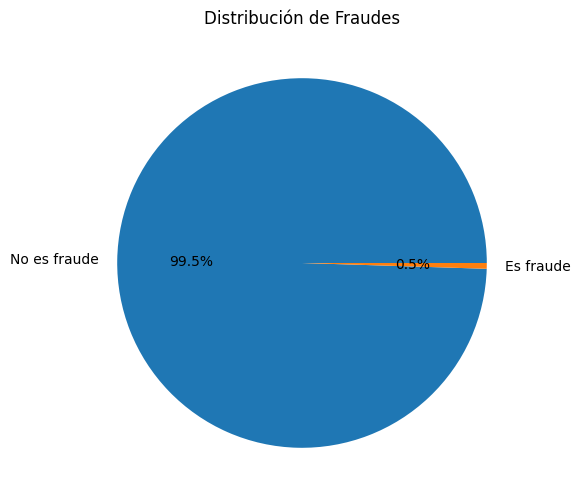

In [4]:
data[target].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6),
    labels=['No es fraude', 'Es fraude'],
)

plt.title("Distribución de Fraudes")
plt.show()

# **DETECCIÓN DE INCONSISTENCIAS**

En esta etapa se evaluaron posibles inconsistencias lógicas dentro del dataset crudo.
Las inconsistencias se definieron como registros que presentan valores imposibles o contradictorios según el contexto del problema. Para ello, se establecieron las siguientes reglas:

- `transaction_amount < 0`: el monto de una transacción no debería ser negativo.
- `account_balance < 0`: el saldo de la cuenta no debería ser negativo.
- `transaction_time_seconds < 0`: el tiempo de la transacción no puede ser menor a cero.
- `transaction_time_seconds > 86400`: el tiempo de la transacción no debería superar los 86400 segundos, equivalentes a un día completo.
- `avg_transaction_amount_7d < 0`: el promedio de transacciones de los últimos 7 días no debería ser negativo.
- `std_transaction_amount_7d < 0`: la desviación estándar de los montos de los últimos 7 días no debería ser negativa.
- `transactions_last_1h < 0`: la cantidad de transacciones realizadas en la última hora no puede ser negativa.
- `transactions_last_24h < 0`: la cantidad de transacciones realizadas en las últimas 24 horas no puede ser negativa.
- `failed_attempts < 0`: la cantidad de intentos fallidos no debería ser negativa.
- `num_devices_used < 1`: la cantidad de dispositivos utilizados debe ser al menos 1.
- `transactions_last_1h > transactions_last_24h`: no debería haber más transacciones registradas en la última hora que en las últimas 24 horas.


In [5]:
data.dtypes

transaction_amount           float64
account_balance              float64
transaction_time_seconds       int64
avg_transaction_amount_7d    float64
std_transaction_amount_7d    float64
transactions_last_1h           int64
transactions_last_24h          int64
failed_attempts                int64
num_devices_used               int64
transaction_type                 str
device_type                      str
location_region                  str
is_foreign_transaction         int64
is_high_risk_country           int64
is_fraud                       int64
dtype: object

In [6]:
# Detección de registros inconsistentes

inconsistencias = data[(
    (data["transaction_amount"] < 0) |
    (data["account_balance"] < 0) |
    (data["transaction_time_seconds"] < 0) |
    (data["transaction_time_seconds"] > 86400) |
    (data["avg_transaction_amount_7d"] < 0) |
    (data["std_transaction_amount_7d"] < 0) |
    (data["transactions_last_1h"] < 0) |
    (data["transactions_last_24h"] < 0) |
    (data["failed_attempts"] < 0) |
    (data["num_devices_used"] < 1) |
    (data["transactions_last_1h"] > data["transactions_last_24h"])
)]
print("Registros inconsistentes encontrados: ")
display(inconsistencias)

Registros inconsistentes encontrados: 


,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,transaction_type,device_type,location_region,is_foreign_transaction,is_high_risk_country,is_fraud
80,64.128373,784.250243,538,50.372845,39.302942,7,6,0,1,payment,desktop,urban,0,0,0
334,63.113261,783.630635,68157,96.314775,55.735336,2,1,1,2,withdrawal,mobile,suburban,0,0,0
392,87.042131,1218.003254,9361,114.442151,50.191326,3,2,1,4,purchase,desktop,suburban,0,0,0
482,50.941443,3172.503282,7898,99.070738,38.687299,5,3,1,1,purchase,tablet,suburban,0,0,0
1226,90.689355,5182.111977,37189,1.000000,4.989097,5,4,1,4,withdrawal,mobile,rural,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18368,98.859377,3636.135128,86290,121.139788,22.401101,8,6,0,4,payment,desktop,urban,0,0,0
18405,175.883137,2798.254752,74051,63.990331,61.480366,5,1,0,3,withdrawal,desktop,suburban,0,0,0
18764,144.852278,2054.175259,31799,1.000000,26.015647,7,6,0,1,transfer,mobile,urban,0,0,0
18879,15.317119,3354.080500,85290,92.717124,7.126720,6,1,1,4,transfer,mobile,urban,0,0,0


# **CORRECCIÓN DE NUMEROS NEGATIVOS**
- "num_devices_used", se corrigue para que sea minimo 1.
- Las demas columnas de variables numericas continuas que contengan valores negativos, las corregiremos usando valor absoluto.

In [7]:
columns_to_correct = [
 "transaction_amount", "account_balance", "transaction_time_seconds", "avg_transaction_amount_7d",
 "std_transaction_amount_7d", "transactions_last_1h", "transactions_last_24h",
 "failed_attempts"
]

# Correguimos num_devices_used para que sea minimo 1.
data['num_devices_used'] = data['num_devices_used'].clip(lower=1)

# Valor absoluto.
for col in columns_to_correct:
    data[col] = data[col].abs()

#Volvemos a detectar inconsistencias
inconsistencias2 = data[(data["transaction_amount"] < 0) |
 (data["account_balance"] < 0) | (data["transaction_time_seconds"] < 0) |
  (data["avg_transaction_amount_7d"] < 0) | (data["std_transaction_amount_7d"] < 0) |
(data["transactions_last_1h"] < 0) | (data["transactions_last_24h"] < 0) |
(data["failed_attempts"] < 0) | (data["num_devices_used"] < 1)
  ]
print("Registros inconsistentes encontrados después de la corrección:")
display(inconsistencias2)

Registros inconsistentes encontrados después de la corrección:


,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,transaction_type,device_type,location_region,is_foreign_transaction,is_high_risk_country,is_fraud


# **DETECCION DE ATÍPICOS**

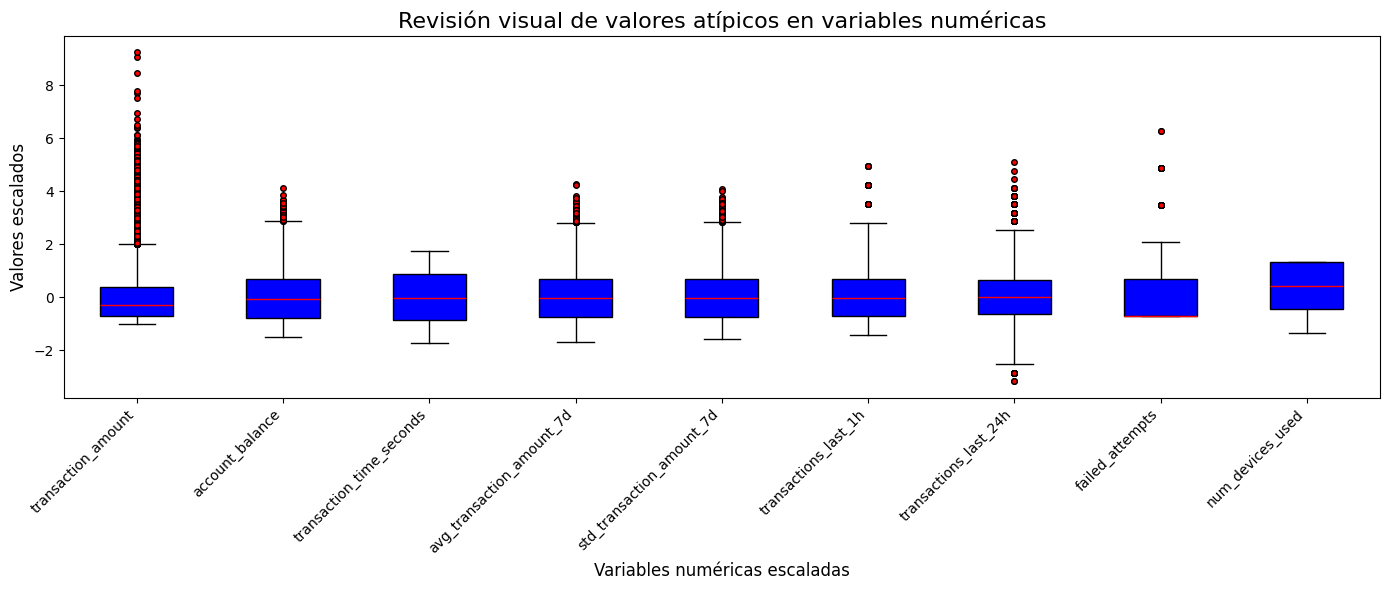

In [8]:
# Revisión visual de valores atípicos

# Variables numéricas seleccionadas para revisión de atípicos
variables_atipicos = [
    "transaction_amount",
    "account_balance",
    "transaction_time_seconds",
    "avg_transaction_amount_7d",
    "std_transaction_amount_7d",
    "transactions_last_1h",
    "transactions_last_24h",
    "failed_attempts",
    "num_devices_used"
]

# Escalamiento

scaler = StandardScaler()
datos_escalados = scaler.fit_transform(data[variables_atipicos])

data_temporal = pd.DataFrame(
    datos_escalados,
    columns=variables_atipicos
)

# Boxplot de variables escaladas
plt.figure(figsize=(14, 6))

data_temporal.boxplot(
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor="blue", color="black"),
    medianprops=dict(color="red"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(marker="o", markerfacecolor="red", markersize=4, linestyle="none")
)

plt.title("Revisión visual de valores atípicos en variables numéricas", fontsize=16)
plt.xlabel("Variables numéricas escaladas", fontsize=12)
plt.ylabel("Valores escalados", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretación de la revisión visual de valores atípicos

En el gráfico se observa un boxplot de las variables numéricas previamente escaladas mediante `StandardScaler`. Este escalamiento permite comparar variables que originalmente se encuentran en rangos distintos, como montos de transacción, tiempos, saldos, cantidad de intentos fallidos y número de dispositivos utilizados.

Las variables donde se observa mayor presencia de valores atípicos son:

- `transaction_amount`: presenta varios valores extremos positivos, lo que podría indicar transacciones con montos inusualmente altos.
- `account_balance`: muestra algunos valores superiores alejados del rango principal, asociados a cuentas con saldos elevados.
- `avg_transaction_amount_7d`: presenta valores altos respecto al promedio general, lo que puede indicar usuarios con comportamiento transaccional superior al habitual.
- `std_transaction_amount_7d`: muestra dispersión elevada en algunos registros, lo que puede reflejar alta variabilidad en los montos de transacción recientes.
- `transactions_last_1h` y `transactions_last_24h`: presentan valores extremos que podrían representar actividad transaccional inusual en periodos cortos.
- `failed_attempts`: muestra algunos casos extremos, lo que puede ser relevante en un contexto de fraude, ya que múltiples intentos fallidos pueden asociarse a accesos no autorizados.
- `num_devices_used`: no presenta tantos valores extremos visibles, pero sigue siendo relevante, ya que un uso elevado de dispositivos podría indicar comportamiento sospechoso.


# **REVISION DE DUPLICADOS**

In [9]:
data.duplicated().sum()

np.int64(0)

No hay presencia de filas duplicadas.

# **Correlación entre variables numericas**

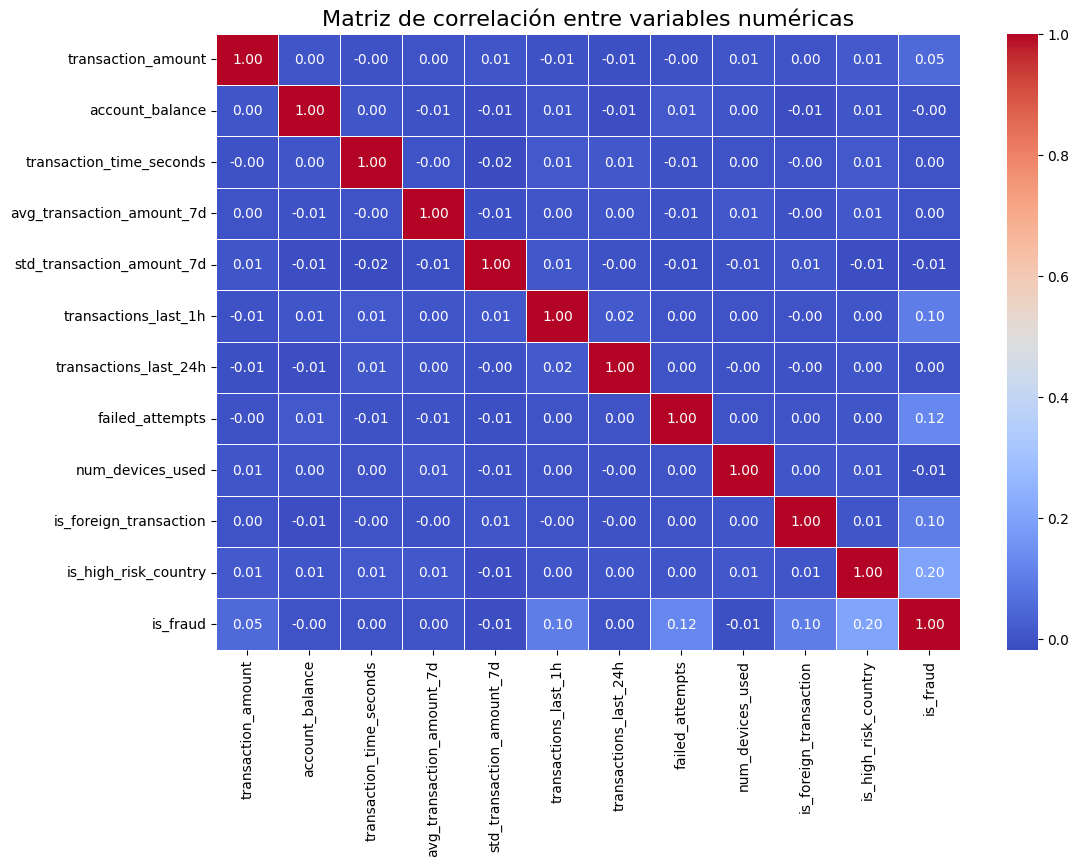

In [10]:
# Variables numéricas y variable objetivo
variables_correlacion = [
    "transaction_amount",
    "account_balance",
    "transaction_time_seconds",
    "avg_transaction_amount_7d",
    "std_transaction_amount_7d",
    "transactions_last_1h",
    "transactions_last_24h",
    "failed_attempts",
    "num_devices_used",
    "is_foreign_transaction",
    "is_high_risk_country",
    "is_fraud"
]

# Calcular matriz de correlación
matriz_correlacion = data[variables_correlacion].corr()

# Visualizar matriz
plt.figure(figsize=(12, 8))
sb.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables numéricas", fontsize=16)
plt.show()

In [11]:
# Correlación de variables con is_fraud

correlacion_objetivo = matriz_correlacion["is_fraud"].sort_values(ascending=False)

display(correlacion_objetivo)

is_fraud                     1.000000
is_high_risk_country         0.201771
failed_attempts              0.121273
transactions_last_1h         0.099618
is_foreign_transaction       0.098992
transaction_amount           0.050008
transactions_last_24h        0.001600
transaction_time_seconds     0.001429
avg_transaction_amount_7d    0.000671
account_balance             -0.000361
num_devices_used            -0.008810
std_transaction_amount_7d   -0.012300
Name: is_fraud, dtype: float64

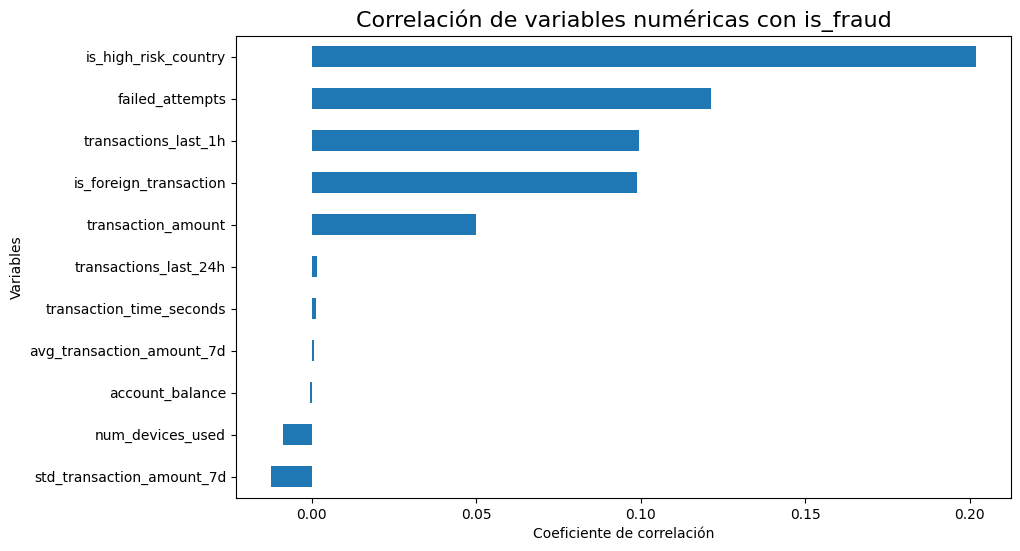

In [12]:
correlacion_objetivo = matriz_correlacion["is_fraud"].drop("is_fraud").sort_values()

plt.figure(figsize=(10, 6))
correlacion_objetivo.plot(kind="barh")

plt.title("Correlación de variables numéricas con is_fraud", fontsize=16)
plt.xlabel("Coeficiente de correlación")
plt.ylabel("Variables")
plt.show()

# **Análisis de correlación con la variable objetivo**

Al analizar la correlación de las variables numéricas con `is_fraud`, se observa que ninguna variable presenta una correlación lineal fuerte con la variable objetivo. Sin embargo, algunas variables muestran una relación positiva mayor que el resto.

La variable con mayor correlación es `is_high_risk_country`, lo que indica que las transacciones realizadas en países de alto riesgo tienden a estar más asociadas con casos de fraude. También destacan `failed_attempts`, `transactions_last_1h`, `is_foreign_transaction` y `transaction_amount`, lo cual es coherente con el contexto del problema, ya que los intentos fallidos, las transacciones extranjeras, la actividad intensa en poco tiempo y los montos elevados pueden representar señales de comportamiento sospechoso.

Por otro lado, variables como `transactions_last_24h`, `transaction_time_seconds`, `avg_transaction_amount_7d` y `account_balance` presentan correlaciones cercanas a cero, lo que indica una relación lineal débil con el fraude de manera individual.


# **PREPROCESAMIENTO**

In [13]:
# DEFINICIÓN DE VARIABLES

# VARIABLE OBJETIVO
target = "is_fraud"

#VARIABLES NUMERICAS
numeric_features = [
    "transaction_amount",
    "account_balance",
    "transaction_time_seconds",
    "avg_transaction_amount_7d",
    "std_transaction_amount_7d",
    "transactions_last_1h",
    "transactions_last_24h",
    "failed_attempts",
    "num_devices_used"
]

#VARIABLES CATEGORICAS
categorical_features = [
    "transaction_type",
    "device_type",
    "location_region"
]
#VARIABLES BINARIAS
binary_features = [
    "is_foreign_transaction",
    "is_high_risk_country"
]


# **SEPARACION VARIABLE OBJETIVO Y VARIABLES PREDICTORAS**

In [14]:
X = data.drop(columns=[target])
y = data[target]

# **SEPARACION TRAIN/TEST**

In [15]:
#SPLIT 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [16]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", 'passthrough', binary_features)
    ]
)

preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

In [17]:
def evaluar_modelo_entrenado(modelo, X_test, y_test):
    """
    Evalúa un modelo ya entrenado sobre el conjunto de prueba.
    """

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }

# **LOGISTIC REGRESSION CON GRIDSEARCHCV**

In [18]:

# Modelo 1: Logistic Regression con GridSearchCV

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipeline_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    "model__solver": ["liblinear", "lbfgs"]
}

grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Mejores hiperparámetros Logistic Regression:")
print(grid_lr.best_params_)

print("\nMejor recall en validación cruzada:")
print(grid_lr.best_score_)

mejor_lr = grid_lr.best_estimator_

metricas_lr = evaluar_modelo_entrenado(
    mejor_lr,
    X_test,
    y_test
)

resultados_lr = pd.DataFrame([metricas_lr], index=["Logistic Regression"])

display(resultados_lr)

Mejores hiperparámetros Logistic Regression:
{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Mejor recall en validación cruzada:
0.7275684212901334


c:\Users\elgab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.997,0.625,1.0,0.769231,1.0


# **DECISION TREE CLASSIFIER CON GRIDSEARCHCV**

In [19]:
# Modelo 2: Decision Tree Classifier con GridSearchCV

pipeline_dt = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_dt = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf": [1, 5, 10],
    "model__criterion": ["gini", "entropy"]
}

grid_dt = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_dt,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Mejores hiperparámetros Decision Tree:")
print(grid_dt.best_params_)

print("\nMejor recall en validación cruzada:")
print(grid_dt.best_score_)
mejor_dt = grid_dt.best_estimator_

metricas_dt = evaluar_modelo_entrenado(
    mejor_dt,
    X_test,
    y_test
)

resultados_dt = pd.DataFrame([metricas_dt], index=["Decision Tree"])

display(resultados_dt)

Mejores hiperparámetros Decision Tree:
{'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Mejor recall en validación cruzada:
0.3284296163606508


,accuracy,precision,recall,f1,roc_auc
Decision Tree,0.996,0.625,0.5,0.555556,0.749246


# **COMPARACION DE MODELOS**

In [20]:
comparacion_modelos = pd.concat([resultados_lr, resultados_dt])

comparacion_modelos["mejor_recall_cv"] = [
    grid_lr.best_score_,
    grid_dt.best_score_
]

comparacion_modelos["mejores_hiperparametros"] = [
    grid_lr.best_params_,
    grid_dt.best_params_
]

display(comparacion_modelos)

,accuracy,precision,recall,f1,roc_auc,mejor_recall_cv,mejores_hiperparametros
Logistic Regression,0.997,0.625,1.0,0.769231,1.000000,0.727568,"{'model__C': 10, 'model__penalty': 'l2', 'mode..."
Decision Tree,0.996,0.625,0.5,0.555556,0.749246,0.328430,"{'model__criterion': 'entropy', 'model__max_de..."


In [21]:
if grid_lr.best_score_ >= grid_dt.best_score_:
    mejor_modelo = grid_lr.best_estimator_
    nombre_mejor_modelo = "Logistic Regression"
    mejores_parametros = grid_lr.best_params_
else:
    mejor_modelo = grid_dt.best_estimator_
    nombre_mejor_modelo = "Decision Tree"
    mejores_parametros = grid_dt.best_params_

print("Mejor modelo seleccionado:", nombre_mejor_modelo)

Mejor modelo seleccionado: Logistic Regression


# **Evaluación base del mejor modelo LR con threshold 0.5**

Una vez seleccionado el mejor modelo, se realiza una evaluación base utilizando el threshold por defecto de 0.5.

In [22]:
# Probabilidades de fraude
y_prob = mejor_modelo.predict_proba(X_test)[:, 1]

# Predicción con threshold 0.5
y_pred_05 = (y_prob >= 0.5).astype(int)

metricas_05 = {
    "threshold": 0.5,
    "accuracy": accuracy_score(y_test, y_pred_05),
    "precision": precision_score(y_test, y_pred_05, zero_division=0),
    "recall": recall_score(y_test, y_pred_05, zero_division=0),
    "f1": f1_score(y_test, y_pred_05, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob)
}

display(pd.DataFrame([metricas_05]))

,threshold,accuracy,precision,recall,f1,roc_auc
0,0.5,0.997,0.625,1.0,0.769231,1.0


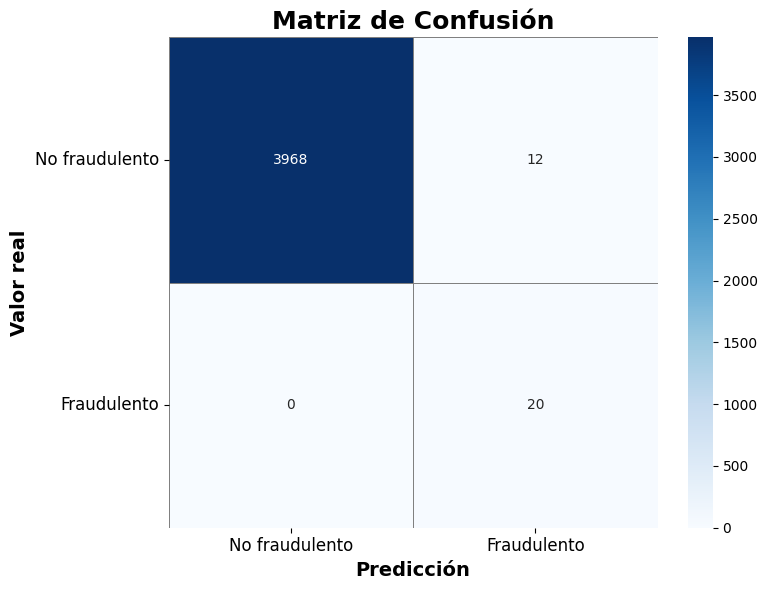

In [23]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_05)

# Etiquetas
labels = ["No fraudulento", "Fraudulento"]

# Gráfico
plt.figure(figsize=(8, 6))
sb.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor="gray"
)

plt.title("Matriz de Confusión", fontsize=18, fontweight="bold")
plt.xlabel("Predicción", fontsize=14, fontweight="bold")
plt.ylabel("Valor real", fontsize=14, fontweight="bold")
plt.xticks(rotation=0, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

# **Evaluación con distintos thresholds**

En esta sección se evalúa el comportamiento del mejor modelo modificando el umbral de decisión. Para ello se utilizan los thresholds 0.3, 0.5 y 0.7.

El uso de `predict_proba` permite obtener la probabilidad estimada de fraude para cada transacción. Luego, según el threshold elegido, se decide si la transacción se clasifica como fraude o no fraude.


Threshold: 0.3
Accuracy : 0.9958
Precision: 0.5405
Recall   : 1.0000
F1-score : 0.7018


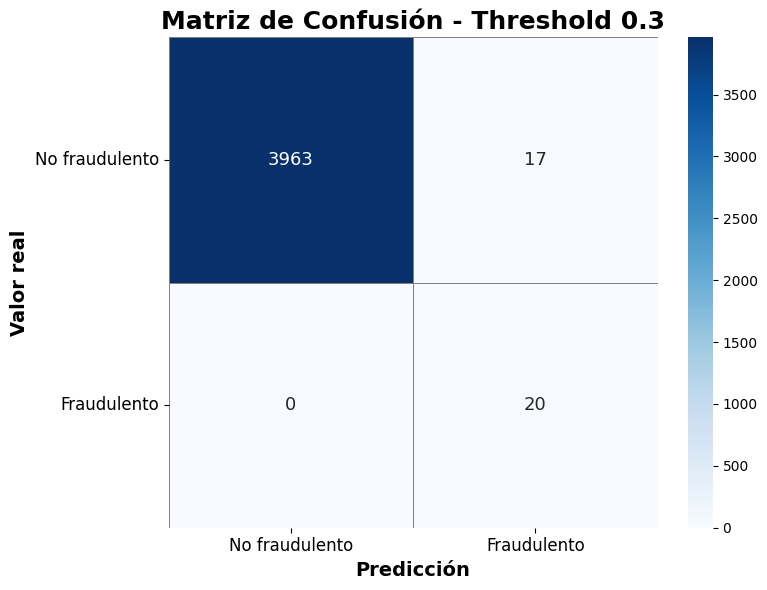

Archivo generado: predicciones_threshold_0_3.csv

Threshold: 0.5
Accuracy : 0.9970
Precision: 0.6250
Recall   : 1.0000
F1-score : 0.7692


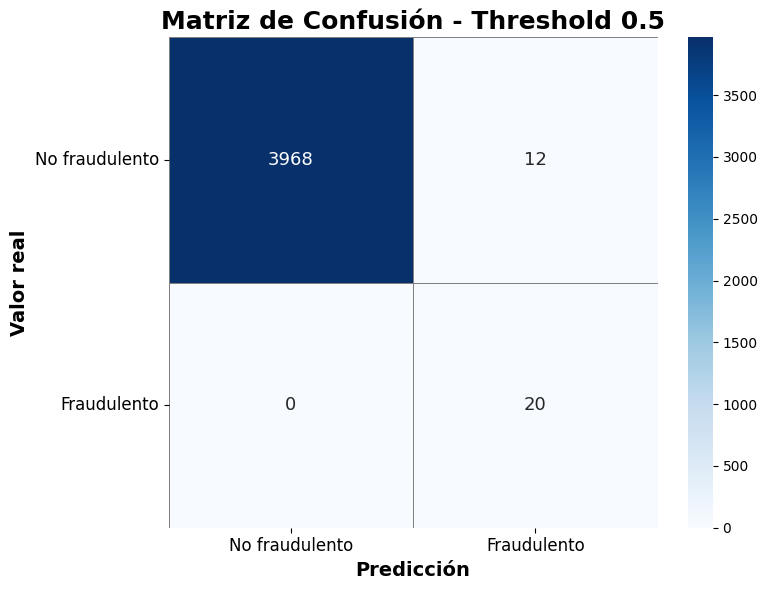

Archivo generado: predicciones_threshold_0_5.csv

Threshold: 0.7
Accuracy : 0.9975
Precision: 0.6667
Recall   : 1.0000
F1-score : 0.8000


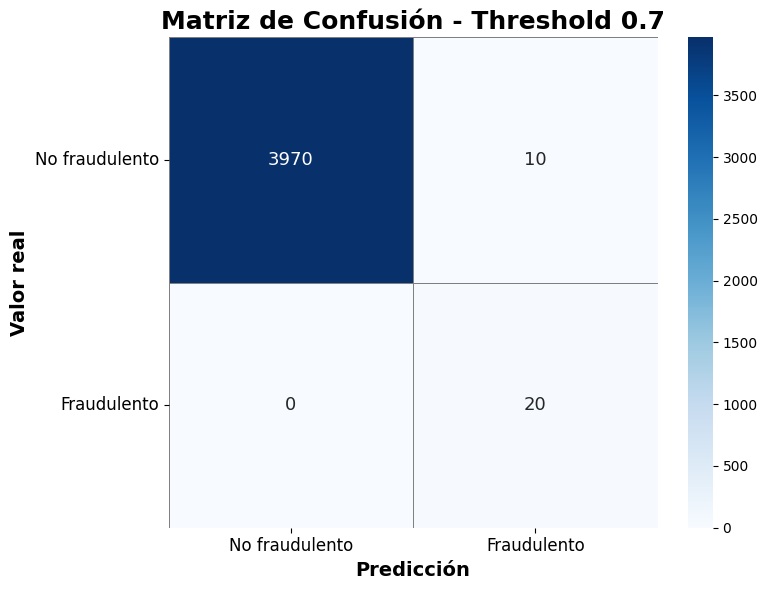

Archivo generado: predicciones_threshold_0_7.csv


,threshold,accuracy,precision,recall,f1,TN,FP,FN,TP
0,0.3,0.99575,0.540541,1.0,0.701754,3963,17,0,20
1,0.5,0.99700,0.625000,1.0,0.769231,3968,12,0,20
2,0.7,0.99750,0.666667,1.0,0.800000,3970,10,0,20


In [24]:
thresholds = [0.3, 0.5, 0.7]

resultados_thresholds = []

for threshold in thresholds:
    
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
    accuracy = accuracy_score(y_test, y_pred_threshold)

    cm = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()

    resultados_thresholds.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    # Matriz de confusión
    labels = ["No fraudulento", "Fraudulento"]

    plt.figure(figsize=(8, 6))
    sb.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5,
        linecolor="gray",
        annot_kws={"size": 13}
    )

    plt.title(f"Matriz de Confusión - Threshold {threshold}", fontsize=18, fontweight="bold")
    plt.xlabel("Predicción", fontsize=14, fontweight="bold")
    plt.ylabel("Valor real", fontsize=14, fontweight="bold")
    plt.xticks(rotation=0, fontsize=12)
    plt.yticks(rotation=0, fontsize=12)
    plt.tight_layout()
    plt.show()

    # -------------------------------
    # CSV con predicciones
    # -------------------------------
    predicciones_csv = X_test.copy()
    predicciones_csv["valor_real"] = y_test.values
    predicciones_csv["probabilidad_fraude"] = y_prob
    predicciones_csv["prediccion"] = y_pred_threshold

    nombre_archivo = f"predicciones_threshold_{str(threshold).replace('.', '_')}.csv"
    predicciones_csv.to_csv(f'../data/cleaned/{nombre_archivo}', index=False)

    print(f"Archivo generado: {nombre_archivo}")

resultados_thresholds = pd.DataFrame(resultados_thresholds)
display(resultados_thresholds)

# **ANÁLISIS COMPARATIVO DE THRESHOLDS**

Al comparar los resultados obtenidos con los thresholds `0.3`, `0.5` y `0.7`, se observa que el modelo mantiene un `recall` de `1.0` en los tres casos evaluados. Esto significa que, dentro del conjunto de prueba, el modelo logró detectar correctamente los `20` casos reales de fraude, sin generar falsos negativos (`FN = 0`).

El conjunto de prueba utilizado contiene `4000` registros en total, de los cuales `3980` corresponden a transacciones no fraudulentas y `20` corresponden a transacciones fraudulentas. Por este motivo, en un problema de fraude es importante no analizar solamente el `accuracy`, ya que la clase fraudulenta es minoritaria. En este caso, métricas como `recall`, `precision` y `F1-score` entregan una interpretación más útil del comportamiento del modelo.

Los resultados obtenidos fueron los siguientes:

- Con threshold `0.3`, el modelo obtuvo `accuracy = 0.99575`, `precision = 0.5405`, `recall = 1.0` y `F1-score = 0.7018`. La matriz de confusión fue: `TN = 3963`, `FP = 17`, `FN = 0`, `TP = 20`.
- Con threshold `0.5`, el modelo obtuvo `accuracy = 0.9970`, `precision = 0.6250`, `recall = 1.0` y `F1-score = 0.7692`. La matriz de confusión fue: `TN = 3968`, `FP = 12`, `FN = 0`, `TP = 20`.
- Con threshold `0.7`, el modelo obtuvo `accuracy = 0.9975`, `precision = 0.6667`, `recall = 1.0` y `F1-score = 0.8000`. La matriz de confusión fue: `TN = 3970`, `FP = 10`, `FN = 0`, `TP = 20`.

A medida que aumenta el threshold, el modelo se vuelve más estricto para clasificar una transacción como fraudulenta. Esto permite reducir la cantidad de falsos positivos, pasando de `17` falsos positivos con threshold `0.3`, a `12` con threshold `0.5` y finalmente a `10` con threshold `0.7`.

Este comportamiento es positivo, porque el modelo mantiene la detección completa de fraudes reales (`recall = 1.0`) y, al mismo tiempo, mejora la precisión y el F1-score. En otras palabras, el threshold `0.7` logra un mejor equilibrio entre detectar fraudes y evitar marcar transacciones legítimas como fraudulentas.


# **DECISIÓN DE NEGOCIO**

De los thresholds analizados, elegiría el threshold `0.7`.

La principal razón es que este threshold mantiene un `recall = 1.0`, por lo que detecta los `20` fraudes reales presentes en el conjunto de prueba y no deja pasar fraudes sin detectar (`FN = 0`). En el contexto de fraude, esto es fundamental, porque un falso negativo representa una transacción fraudulenta clasificada como legítima, lo que puede generar pérdidas económicas para la empresa.

Además, el threshold `0.7` es el que obtiene el mejor `F1-score`, con un valor de `0.8000`. Esto indica que tiene el mejor equilibrio entre `precision` y `recall` dentro de las opciones evaluadas. También presenta la mejor precisión (`0.6667`), lo que significa que, de todas las transacciones clasificadas como fraude, una mayor proporción corresponde realmente a fraudes.

Desde el punto de vista operacional, el threshold `0.7` también reduce la cantidad de falsos positivos. Con threshold `0.3` se generan `17` falsos positivos, con threshold `0.5` se generan `12` y con threshold `0.7` se generan `10`. Esto es importante porque cada falso positivo puede significar bloquear o revisar manualmente una transacción legítima, afectando la experiencia del cliente y aumentando la carga de trabajo del equipo encargado de revisar alertas.

Por lo tanto, considerando el contexto de fraude, el threshold `0.7` es la mejor alternativa entre las evaluadas, porque mantiene la detección total de fraudes reales, reduce los errores sobre clientes legítimos y obtiene el mayor F1-score.


# **CONCLUSIONES**

El modelo con mejor desempeño fue `Logistic Regression`. Al cambiar el `scoring` de `GridSearchCV` a `F1-score`, el modelo logró un mejor equilibrio entre la detección de fraudes y la reducción de errores en la clasificación. En el conjunto de prueba, Logistic Regression obtuvo `accuracy = 0.9970`, `precision = 0.6250`, `recall = 1.0`, `F1-score = 0.7692` y `ROC AUC = 1.0` usando el threshold base de `0.5`.

En comparación, `Decision Tree Classifier` obtuvo `accuracy = 0.9960`, `precision = 0.6250`, `recall = 0.5`, `F1-score = 0.5556` y `ROC AUC = 0.7492`. Aunque su accuracy fue alta, su recall fue bastante menor, ya que solo detectó la mitad de los fraudes reales. Por este motivo, Decision Tree no resulta tan conveniente para este problema, donde dejar pasar fraudes puede ser más grave que generar algunas alertas falsas.

Al evaluar distintos thresholds con el mejor modelo, se observó que el threshold `0.7` entrega el mejor resultado general. Este threshold obtuvo `accuracy = 0.9975`, `precision = 0.6667`, `recall = 1.0` y `F1-score = 0.8000`. Además, su matriz de confusión mostró `3970` verdaderos negativos, `10` falsos positivos, `0` falsos negativos y `20` verdaderos positivos.

Esto significa que el modelo detectó todos los fraudes reales del conjunto de prueba y, al mismo tiempo, redujo la cantidad de transacciones legítimas clasificadas incorrectamente como fraude. En términos de negocio, esto es importante porque permite proteger a la empresa frente a transacciones fraudulentas sin afectar innecesariamente a tantos clientes legítimos.

Las variables que parecen más relevantes para explicar el fraude, según el análisis realizado, son principalmente `is_high_risk_country`, `failed_attempts`, `transactions_last_1h`, `is_foreign_transaction` y `transaction_amount`. Estas variables son coherentes con el problema, ya que los países de alto riesgo, los intentos fallidos, muchas transacciones en poco tiempo, las transacciones extranjeras y los montos elevados pueden asociarse a comportamientos sospechosos.

Como conclusión final, el modelo recomendado es `Logistic Regression` con threshold `0.7`, ya que alcanza el mejor `F1-score`, mantiene un `recall` perfecto y reduce los falsos positivos respecto a thresholds más bajos. Sin embargo, debido a que el dataset está fuertemente desbalanceado, sería recomendable seguir mejorando el modelo con técnicas como ajuste de variables, revisión de outliers, validación con más datos reales, balanceo de clases o comparación con modelos adicionales.
